### IMPORT LIBRARY

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

### LOAD DATASET

In [93]:
df = pd.read_csv('customerData_500k.csv')
df.head()

,CustomerID,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus,PromoCode
0,CUST1000000,37.0,57722.572411,19,5.908826,1.093430,11,M,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1,SAVE10
1,CUST1000001,63.0,21328.925876,10,6.970749,0.649246,20,Female,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0,FREESHIP
2,CUST1000002,60.0,150537.742465,19,35.004954,3.858211,25,Male,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0,NONE
3,CUST1000003,19.0,63508.762549,10,14.818000,7.554374,20,Male,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0,NONE
4,CUST1000004,54.0,100399.558368,19,55.925462,0.197411,92,Male,Electronics,Mobile,SOUTH,Referral,Regular,1,4,1,2,0,NONE


### DATA UNDERSTANDING

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502500 entries, 0 to 502499
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   CustomerID            502500 non-null  object 
 1   Age                   487417 non-null  float64
 2   AnnualIncome          487486 non-null  float64
 3   NumberOfPurchases     502500 non-null  int64  
 4   TimeSpentOnWebsite    502500 non-null  float64
 5   CustomerTenureYears   502500 non-null  float64
 6   LastPurchaseDaysAgo   502500 non-null  int64  
 7   Gender                487419 non-null  object 
 8   ProductCategory       502500 non-null  object 
 9   PreferredDevice       502500 non-null  object 
 10  Region                487425 non-null  object 
 11  ReferralSource        502500 non-null  object 
 12  CustomerSegment       502500 non-null  object 
 13  LoyaltyProgram        502500 non-null  int64  
 14  DiscountsAvailed      502500 non-null  int64  
 15  

In [95]:
df.columns

Index(['CustomerID', 'Age', 'AnnualIncome', 'NumberOfPurchases',
       'TimeSpentOnWebsite', 'CustomerTenureYears', 'LastPurchaseDaysAgo',
       'Gender', 'ProductCategory', 'PreferredDevice', 'Region',
       'ReferralSource', 'CustomerSegment', 'LoyaltyProgram',
       'DiscountsAvailed', 'SessionCount', 'CustomerSatisfaction',
       'PurchaseStatus', 'PromoCode'],
      dtype='object')

In [96]:
df.describe()

,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus
count,487417.000000,4.874860e+05,502500.000000,502500.000000,502500.000000,502500.000000,502500.000000,502500.000000,502500.000000,502500.000000,502500.000000
mean,43.932799,8.861056e+04,11.387751,32.311521,2.163232,60.186953,0.501146,3.154740,2.702300,3.219628,0.418352
std,15.754045,6.560326e+04,6.000875,31.243341,2.197367,54.885166,0.499999,1.879326,5.513613,0.826430,0.493289
min,15.000000,1.196639e+04,-1.000000,-3.804161,-0.418429,-11.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,30.000000,5.214040e+04,6.000000,15.921025,0.591980,16.000000,0.000000,2.000000,1.000000,3.000000,0.000000
50%,44.000000,8.406014e+04,12.000000,30.911393,1.465732,31.000000,1.000000,3.000000,2.000000,3.000000,0.000000
75%,57.000000,1.170428e+05,16.000000,45.242071,3.009295,105.000000,1.000000,5.000000,3.000000,4.000000,1.000000
max,81.000000,1.199910e+06,28.000000,599.890350,15.346356,189.000000,1.000000,10.000000,119.000000,5.000000,1.000000


In [97]:
df.isnull().sum()

CustomerID                  0
Age                     15083
AnnualIncome            15014
NumberOfPurchases           0
TimeSpentOnWebsite          0
CustomerTenureYears         0
LastPurchaseDaysAgo         0
Gender                  15081
ProductCategory             0
PreferredDevice             0
Region                  15075
ReferralSource              0
CustomerSegment             0
LoyaltyProgram              0
DiscountsAvailed            0
SessionCount                0
CustomerSatisfaction        0
PurchaseStatus              0
PromoCode                   0
dtype: int64

In [98]:
df.shape

(502500, 19)

In [99]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing (%)', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

              Missing Count  Missing (%)
Age                   15083     3.001592
Gender                15081     3.001194
Region                15075     3.000000
AnnualIncome          15014     2.987861


In [100]:
df.duplicated().sum()

np.int64(2500)

In [101]:
df.head()

,CustomerID,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus,PromoCode
0,CUST1000000,37.0,57722.572411,19,5.908826,1.093430,11,M,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1,SAVE10
1,CUST1000001,63.0,21328.925876,10,6.970749,0.649246,20,Female,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0,FREESHIP
2,CUST1000002,60.0,150537.742465,19,35.004954,3.858211,25,Male,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0,NONE
3,CUST1000003,19.0,63508.762549,10,14.818000,7.554374,20,Male,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0,NONE
4,CUST1000004,54.0,100399.558368,19,55.925462,0.197411,92,Male,Electronics,Mobile,SOUTH,Referral,Regular,1,4,1,2,0,NONE


In [102]:
df['Gender'].value_counts()

Gender
Male      110708
Female    108643
male       86202
female     84399
M          49254
F          48213
Name: count, dtype: int64

In [103]:
df['Region'].value_counts()

Region
south    52926
South    52653
SOUTH    44258
North    36839
north    36523
         ...  
nOrth      538
NOrTh      537
NoRtH      530
NORtH      528
NOrth      513
Name: count, Length: 96, dtype: int64

### EXPLORATORY DATA ANALYSIS (EDA)

In [104]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

In [105]:
numerical_cols

Index(['Age', 'AnnualIncome', 'NumberOfPurchases', 'TimeSpentOnWebsite',
       'CustomerTenureYears', 'LastPurchaseDaysAgo', 'LoyaltyProgram',
       'DiscountsAvailed', 'SessionCount', 'CustomerSatisfaction',
       'PurchaseStatus'],
      dtype='object')

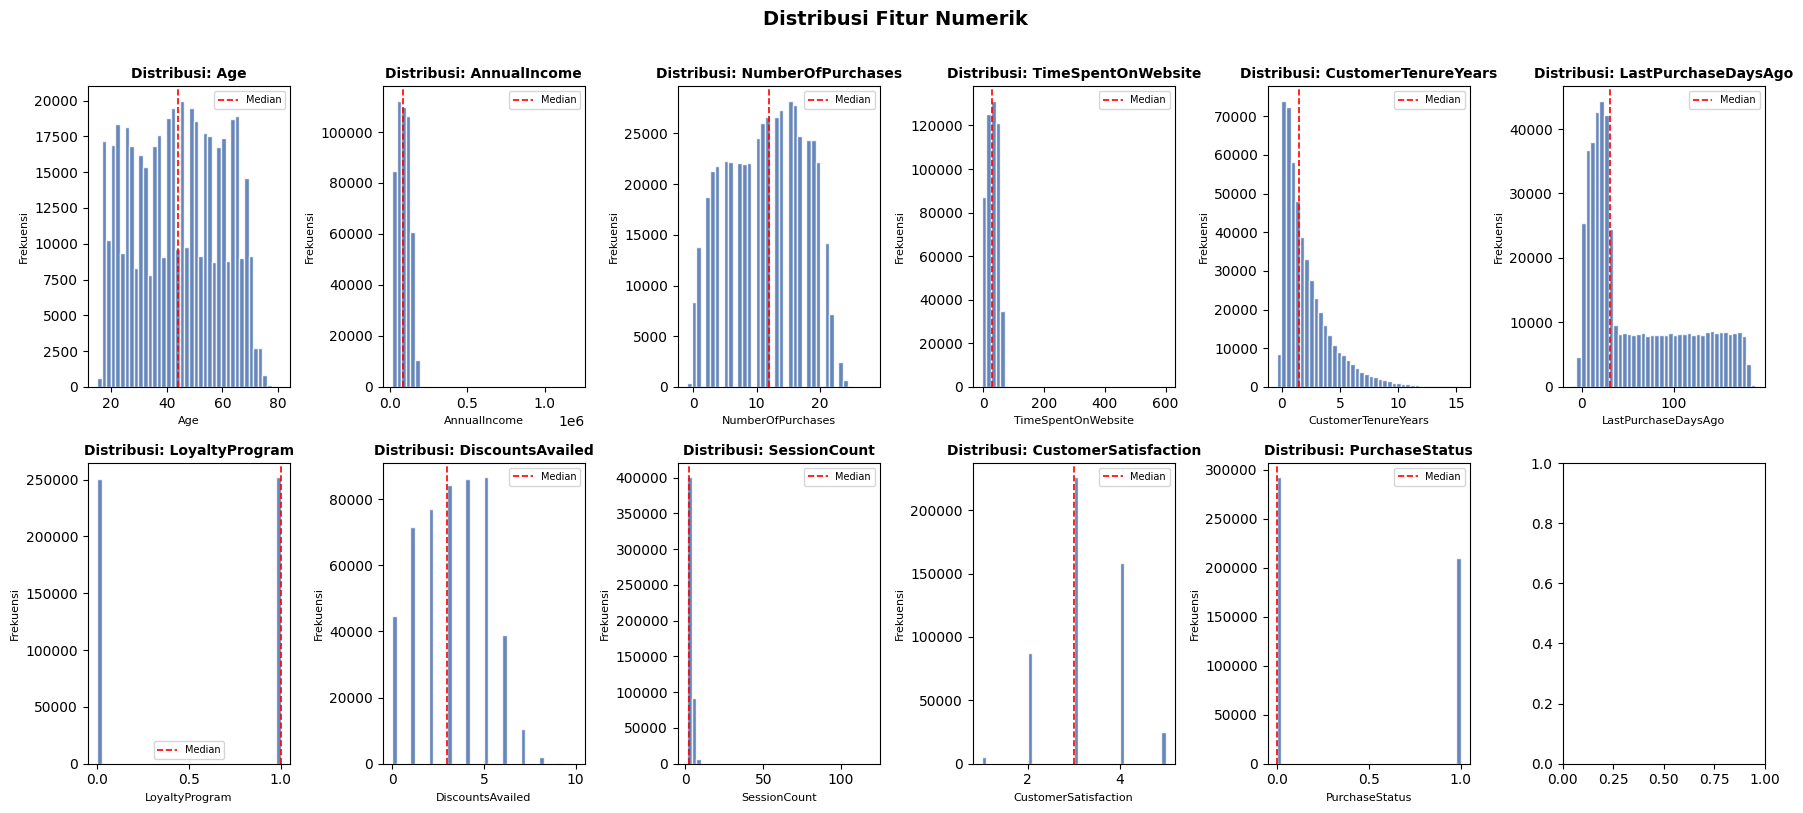

In [106]:
# Distribusi Fitur Numerik
fig, axes = plt.subplots(2, 6, figsize=(18, 8))
axes = axes.flatten()
 
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribusi: {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Frekuensi', fontsize=8)
    axes[i].axvline(df[col].median(), color='red', linestyle='--', linewidth=1.2, label='Median')
    axes[i].legend(fontsize=7)
 
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_numeric_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

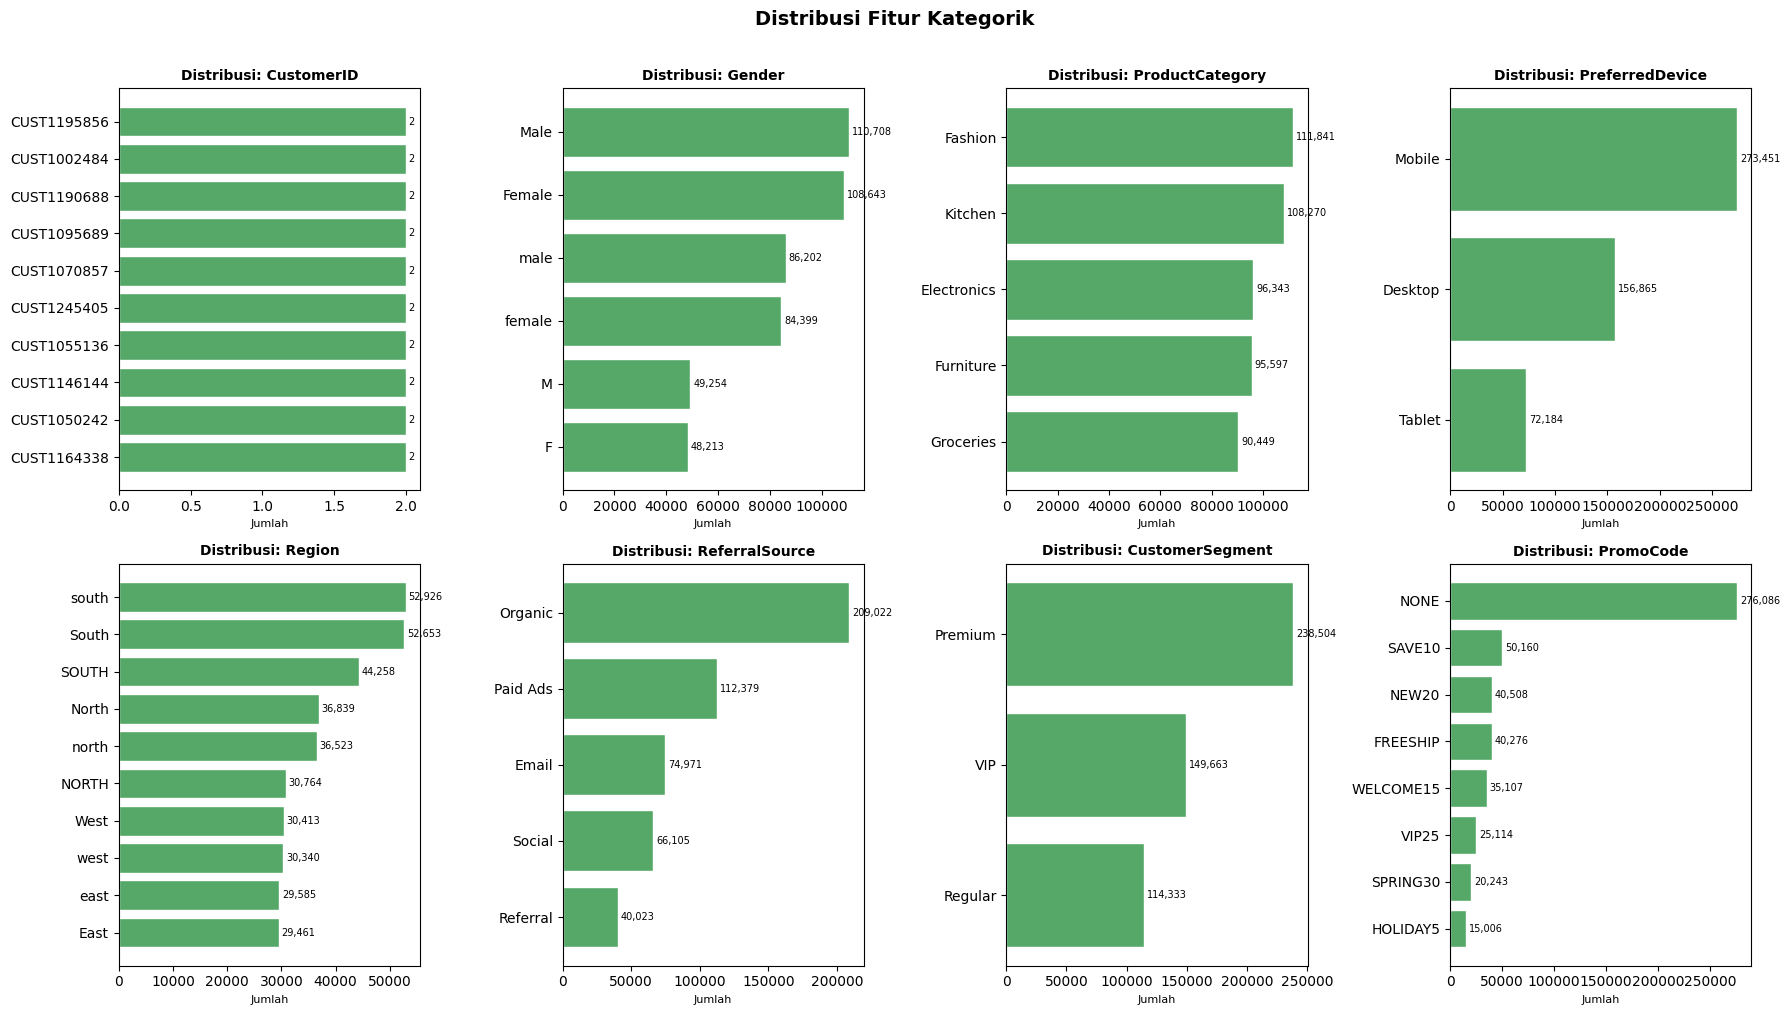

In [107]:
# Distribusi Fitur Kategorik
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
 
for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts().head(10)
    axes[i].barh(counts.index.astype(str), counts.values, color='#55A868', edgecolor='white')
    axes[i].set_title(f'Distribusi: {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Jumlah', fontsize=8)
    axes[i].invert_yaxis()
    for j, v in enumerate(counts.values):
        axes[i].text(v + counts.values.max() * 0.01, j, f'{v:,}', va='center', fontsize=7)
 
plt.suptitle('Distribusi Fitur Kategorik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_categorical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

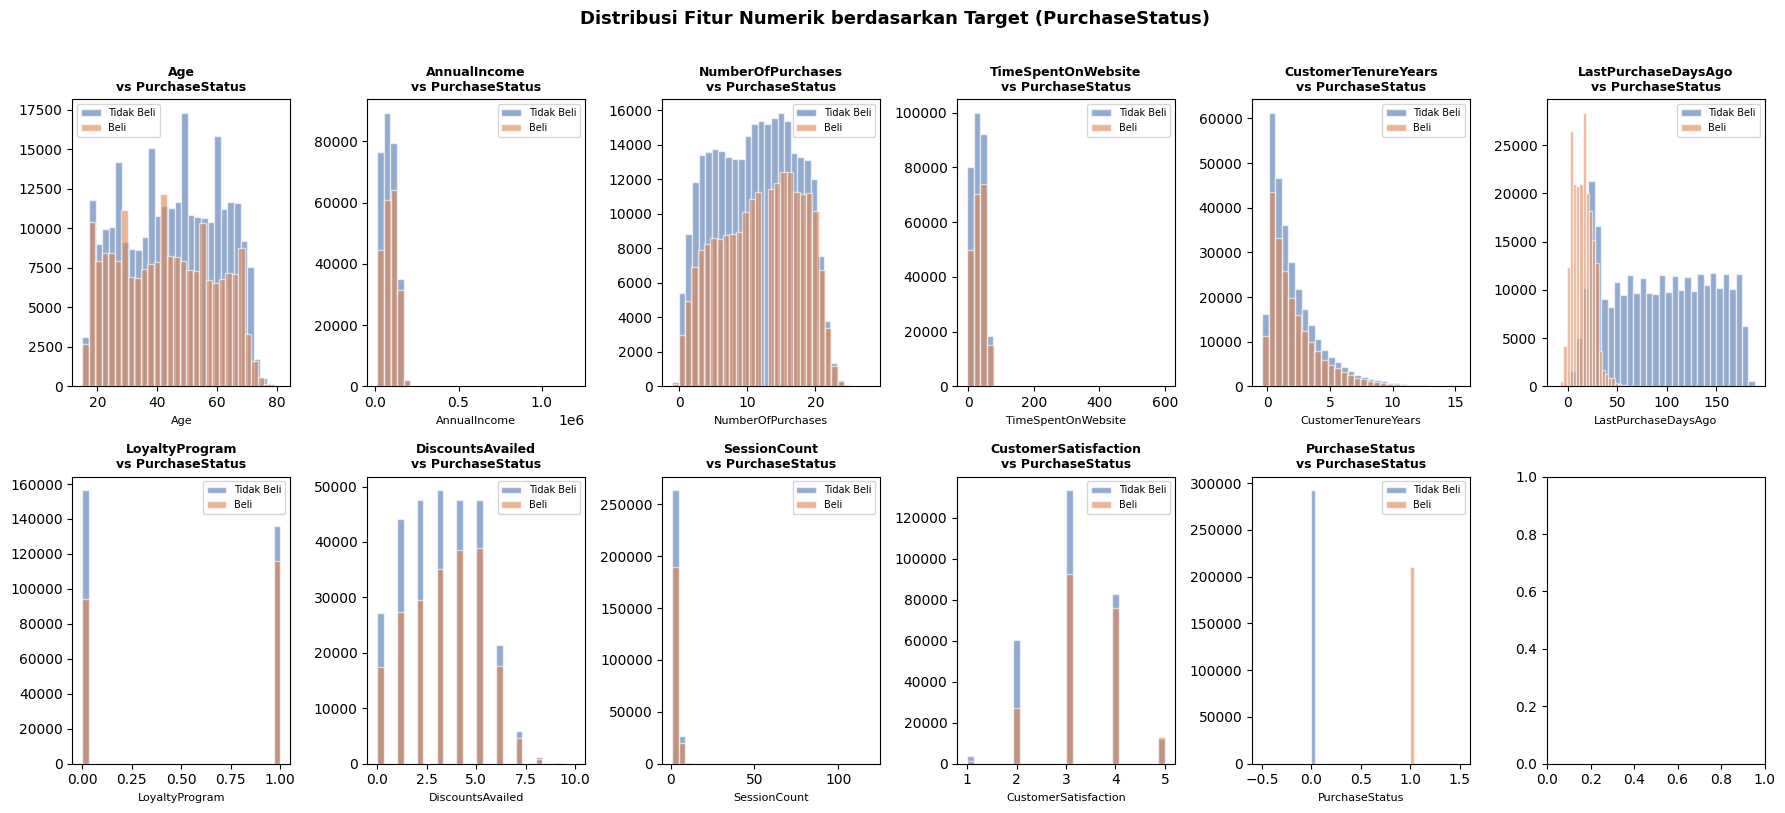

In [108]:
fig, axes = plt.subplots(2, 6, figsize=(18, 8))
axes = axes.flatten()
 
for i, col in enumerate(numerical_cols):
    for status, color, label in [(0, '#4C72B0', 'Tidak Beli'), (1, '#DD8452', 'Beli')]:
        data = df[df['PurchaseStatus'] == status][col].dropna()
        axes[i].hist(data, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(f'{col}\nvs PurchaseStatus', fontsize=9, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].legend(fontsize=7)
 
plt.suptitle('Distribusi Fitur Numerik berdasarkan Target (PurchaseStatus)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_numeric_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

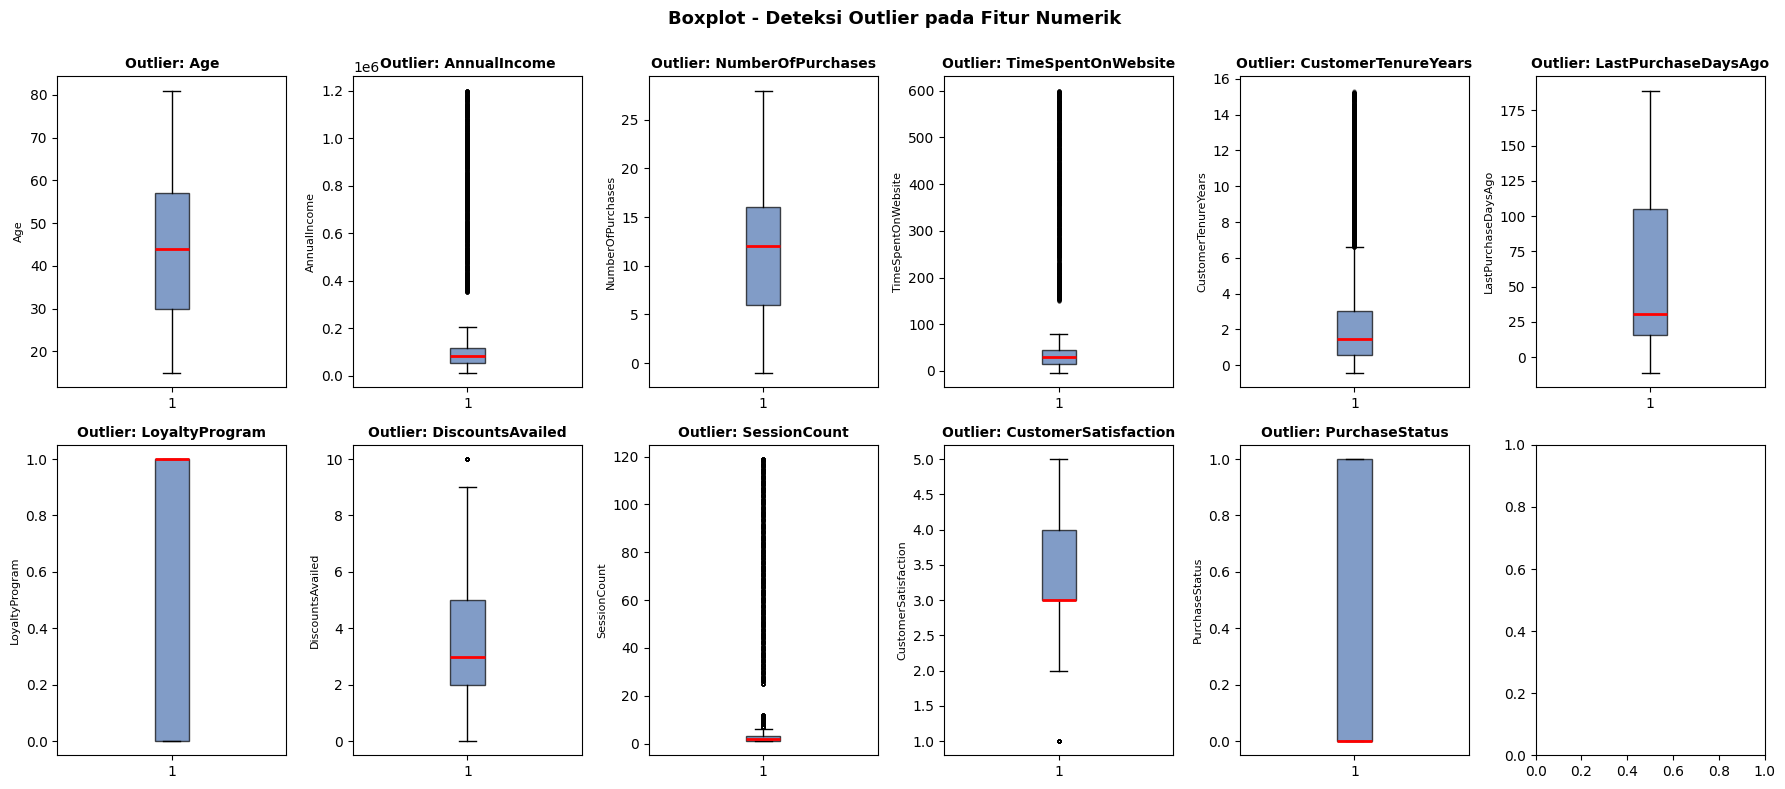

In [109]:
# Box Plot
fig, axes = plt.subplots(2, 6, figsize=(18, 8))
axes = axes.flatten()
 
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[i].set_title(f'Outlier: {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=8)
 
plt.suptitle('Boxplot - Deteksi Outlier pada Fitur Numerik',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplot_outlier.png', dpi=150)
plt.show()

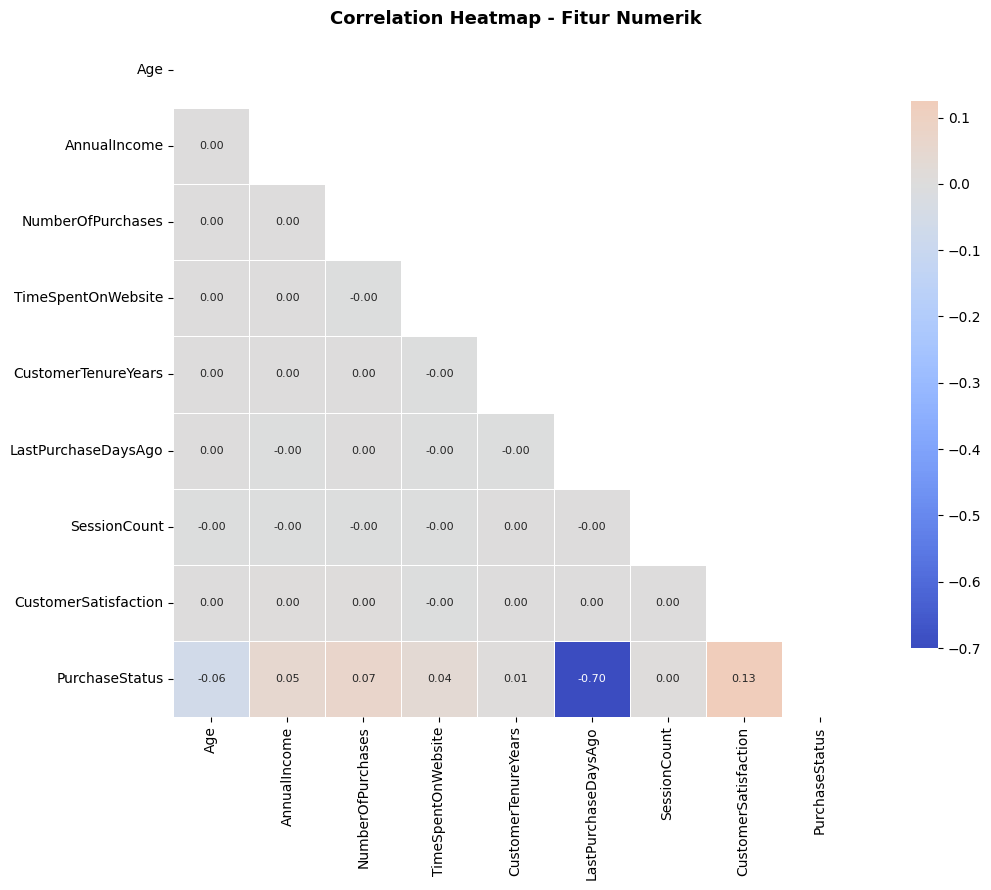

In [110]:
# Correlation Matrix

numeric_for_corr = df.select_dtypes(include=[np.number]).drop(
    columns=['LoyaltyProgram', 'DiscountsAvailed'], errors='ignore'
)
 
corr_matrix = numeric_for_corr.corr()
 
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap - Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150)
plt.show()

In [111]:
for col in numerical_cols:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    pct = outliers / len(df) * 100
    print(f"  {col:<25} → outlier: {outliers:>7,} ({pct:.2f}%)")

  Age                       → outlier:       0 (0.00%)
  AnnualIncome              → outlier:   2,518 (0.50%)
  NumberOfPurchases         → outlier:       0 (0.00%)
  TimeSpentOnWebsite        → outlier:   2,520 (0.50%)
  CustomerTenureYears       → outlier:  24,927 (4.96%)
  LastPurchaseDaysAgo       → outlier:       0 (0.00%)
  LoyaltyProgram            → outlier:       0 (0.00%)
  DiscountsAvailed          → outlier:      59 (0.01%)
  SessionCount              → outlier:   9,963 (1.98%)
  CustomerSatisfaction      → outlier:   5,300 (1.05%)
  PurchaseStatus            → outlier:       0 (0.00%)


### FEATURE ENGINEERING & PREPROCESSING

In [112]:
df_clean = df.copy()
df_clean

,CustomerID,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus,PromoCode
0,CUST1000000,37.0,57722.572411,19,5.908826,1.093430,11,M,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1,SAVE10
1,CUST1000001,63.0,21328.925876,10,6.970749,0.649246,20,Female,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0,FREESHIP
2,CUST1000002,60.0,150537.742465,19,35.004954,3.858211,25,Male,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0,NONE
3,CUST1000003,19.0,63508.762549,10,14.818000,7.554374,20,Male,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0,NONE
4,CUST1000004,54.0,100399.558368,19,55.925462,0.197411,92,Male,Electronics,Mobile,SOUTH,Referral,Regular,1,4,1,2,0,NONE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502495,CUST1185437,27.0,73530.804256,2,26.477834,0.020033,162,male,Furniture,Mobile,SOUTH,Social,Premium,0,5,5,4,0,SPRING30
502496,CUST1400281,62.0,82796.350352,12,18.580715,1.461085,15,Female,Fashion,Mobile,south,Email,Premium,1,0,3,4,1,NONE
502497,CUST1104810,57.0,82185.805722,8,38.748599,3.893059,8,female,Kitchen,Desktop,East,Email,Premium,1,2,7,4,1,SAVE10
502498,CUST1206846,52.0,65062.908768,20,30.393767,1.069285,13,F,Electronics,Mobile,NORTH,Email,VIP,1,5,2,3,1,NONE


In [113]:
df_clean.drop(columns=['CustomerID'], inplace=True)

In [114]:
df_clean.shape

(502500, 18)

In [115]:
def standardize_gender(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if val in ['male', 'M']:
        return 'Male'
    elif val in ['female', 'F']:
        return 'Female'
    else:
        return np.nan
 
df_clean['Gender'] = df_clean['Gender'].apply(standardize_gender)
df_clean['Gender'].unique()

array([nan, 'Female', 'Male'], dtype=object)

In [116]:
df_clean['Region'] = df_clean['Region'].str.strip().str.title()
df_clean['Region'].unique()

array(['South', 'East', 'West', 'North', nan], dtype=object)

In [117]:
# Handling Missing Values
numeric_cols_with_missing = ['Age', 'AnnualIncome']
for col in numeric_cols_with_missing:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"{col}: diisi dengan median = {median_val:.2f}")
 
categorical_cols_with_missing = ['Gender', 'Region']
for col in categorical_cols_with_missing:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"{col}: diisi dengan modus = '{mode_val}'")

print(f"\n  Missing values setelah imputasi: {df_clean.isnull().sum().sum()}")

Age: diisi dengan median = 44.00
AnnualIncome: diisi dengan median = 84060.14
Gender: diisi dengan modus = 'Male'
Region: diisi dengan modus = 'South'

  Missing values setelah imputasi: 0


In [118]:
# Encoding
categorical_cols = df_clean.select_dtypes(include='object').columns
le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
 
df_clean.shape

(502500, 18)

In [119]:
df_clean.head()

,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus,PromoCode
0,37.0,57722.572411,19,5.908826,1.093430,11,1,2,0,2,2,1,1,5,3,2,1,4
1,63.0,21328.925876,10,6.970749,0.649246,20,0,2,1,0,1,2,0,4,2,3,0,0
2,60.0,150537.742465,19,35.004954,3.858211,25,1,0,0,2,1,2,1,2,5,2,0,3
3,19.0,63508.762549,10,14.818000,7.554374,20,1,2,0,3,2,0,0,0,1,3,0,3
4,54.0,100399.558368,19,55.925462,0.197411,92,1,0,1,2,3,1,1,4,1,2,0,3


In [120]:
# Label Encoding
segment_order = ['Regular', 'Premium', 'VIP']   
segment_map   = {val: i for i, val in enumerate(segment_order)}
df_clean['CustomerSegment'] = df_clean['CustomerSegment'].astype(str).str.strip().str.title()
df_clean['CustomerSegment'] = df_clean['CustomerSegment'].map(segment_map)
 
n_nan = df_clean['CustomerSegment'].isna().sum()
if n_nan > 0:
    mode_series = df_clean['CustomerSegment'].dropna()
    fallback = int(mode_series.mode()[0]) if len(mode_series) > 0 else 0
    df_clean['CustomerSegment'] = df_clean['CustomerSegment'].fillna(fallback).astype(int)
else:
    df_clean['CustomerSegment'] = df_clean['CustomerSegment'].astype(int)
 

In [121]:
# One Hot Encoding
nominal_features = [
    'Gender', 'ProductCategory', 'PreferredDevice',
    'Region', 'ReferralSource', 'PromoCode'
]
 
df_before_ohe = df_clean.shape[1]
df_clean = pd.get_dummies(df_clean, columns=nominal_features,
                           drop_first=True,   # hindari multikolinearitas
                           dtype=int)
df_after_ohe = df_clean.shape[1]
 
df_clean.shape

(502500, 33)

### SPLIT DATA

In [122]:
X = df_clean.drop(columns=['PurchaseStatus'])
y = df_clean['PurchaseStatus']

In [124]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       
    random_state=42,
    stratify=y           
)

In [125]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### DATA MODELLING

In [126]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,    
    max_depth=10,        
    min_samples_split=5,
    random_state=42,
    n_jobs=-1           
)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [128]:
y_pred_rf  = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
print("\nHasil Evaluasi Random Forest:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Tidak Beli', 'Beli']))


Hasil Evaluasi Random Forest:
  Accuracy  : 0.9120
  ROC-AUC   : 0.9748

Classification Report:
              precision    recall  f1-score   support

  Tidak Beli       0.96      0.89      0.92     58456
        Beli       0.86      0.95      0.90     42044

    accuracy                           0.91    100500
   macro avg       0.91      0.92      0.91    100500
weighted avg       0.92      0.91      0.91    100500



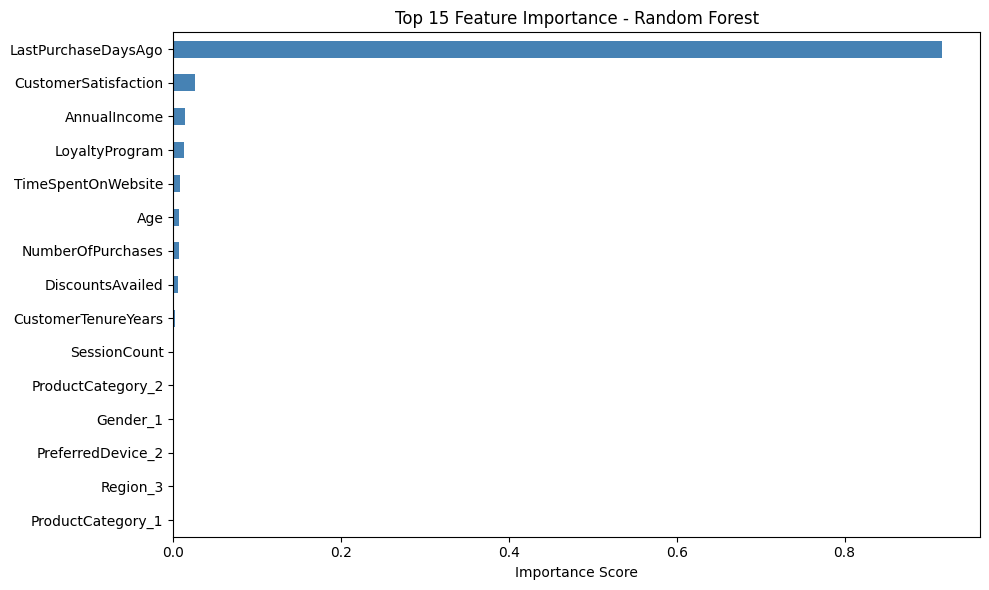

In [129]:
feat_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
 
plt.figure(figsize=(10, 6))
feat_importance.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150)
plt.show()

In [130]:
# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [131]:
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]
print("\nHasil Evaluasi Gradient Boosting:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb,
      target_names=['Tidak Beli', 'Beli']))


Hasil Evaluasi Gradient Boosting:
  Accuracy  : 0.9221
  ROC-AUC   : 0.9788

Classification Report:
              precision    recall  f1-score   support

  Tidak Beli       0.95      0.92      0.93     58456
        Beli       0.89      0.93      0.91     42044

    accuracy                           0.92    100500
   macro avg       0.92      0.92      0.92    100500
weighted avg       0.92      0.92      0.92    100500



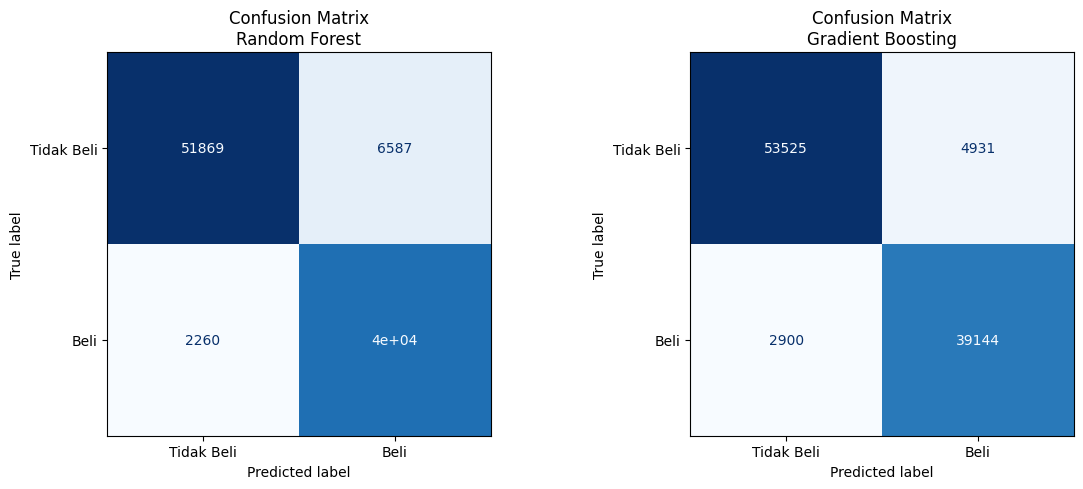

In [132]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_gb],
    ['Random Forest', 'Gradient Boosting']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Tidak Beli', 'Beli'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{title}')
 
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150)
plt.show()

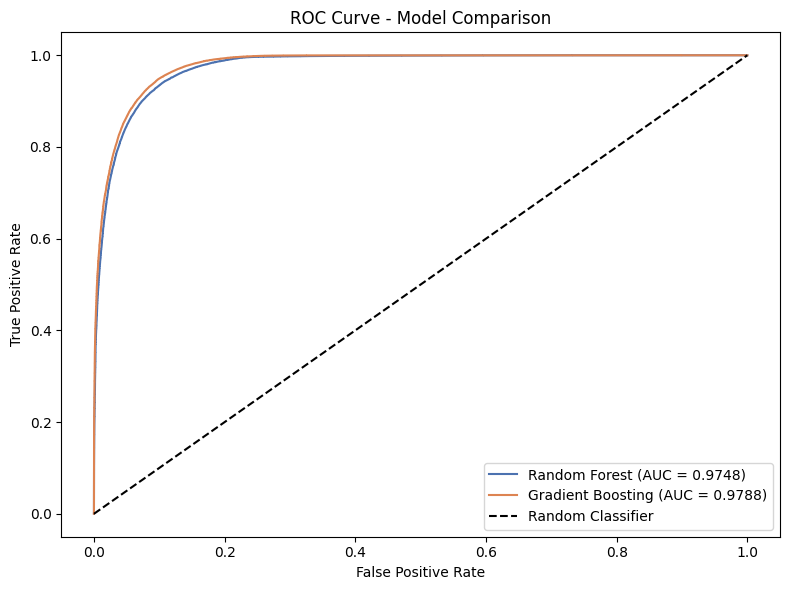

In [133]:
# ROC Curve
plt.figure(figsize=(8, 6))
 
for y_prob, label, color in [
    (y_prob_rf, 'Random Forest',      '#4C72B0'),
    (y_prob_gb, 'Gradient Boosting',  '#DD8452'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score   = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc_score:.4f})', color=color)
 
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150)
plt.show()

In [134]:
summary = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_rf), 4),
        round(accuracy_score(y_test, y_pred_gb), 4),
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_prob_rf), 4),
        round(roc_auc_score(y_test, y_prob_gb), 4),
    ]
})
print(summary.to_string(index=False))
 
best_model = summary.loc[summary['ROC-AUC'].idxmax(), 'Model']
print(f"\nModel terbaik berdasarkan ROC-AUC: {best_model}")
print("PIPELINE SELESAI..")

            Model  Accuracy  ROC-AUC
    Random Forest    0.9120   0.9748
Gradient Boosting    0.9221   0.9788

Model terbaik berdasarkan ROC-AUC: Gradient Boosting
PIPELINE SELESAI..
